## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [ ]:
# @title Ingrese datos
nombre_estudiante = "" # @param {"type":"string"}
carnet = None # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**
Una tienda desea desarrollar un pequeño sistema para controlar la atención de clientes, registrar las operaciones realizadas y administrar su catálogo de productos.

Para resolver el problema se deberán utilizar tres estructuras de datos diferentes

colas

pilas

pilas doblemente enlazadas


## 2) Requerimientos **[2 pts]**

En este problema pudimos identificar 2 funciones principales

RQF 1:Mostrar el último cliente atendido.

RQF 2:Deshacer la última atención.

RQNF 01 (Eficiencia):Al estar usando de estrucutras lineales el almacenamiento de datos es mas accesible por lo que implica menos complejidad a la hora de trabajar con ellos


RQNF 02 (Mantenibilidad): Ya que el código es modular, es más fácil adaptarlo y modificarlo ademas de estar escrito para evitar ciclos infinitos e interrupciones


RQNF 03 (Corrección): Ya que el código es modular, permite ver las funciónes facilmente si hay un error


RQNF 04 (Programar en Python): Programamos en Python porque el lenguaje Python es un lenguaje fácil de comprender el cual se usa más que todo en programas de datos

## 3) Historias de usuario **[2 pts]**
HU01: AGREGAR CLIENTES ATENDIDOS- Como cliente queiro que el programa agregue cada que un cliente sea atendido a la cola de "clientes ya atendidos".

HU02: VISUALIZACION CLIENTES ATENDIDOS- Como cliente quiero que el sistema me muestre claramente el ultimo cliente atendido.

HU03: REVERSION ULTIMA ATENCION- Como cliente quiero que el sistema en caso de que se deba deshacer la ultima atencion, lo elimine de la pila y lo coloque nuevamente al inicio en la lista de clientes pendientes por atender.


## 4) Diagramas de flujo **[5 pts]**
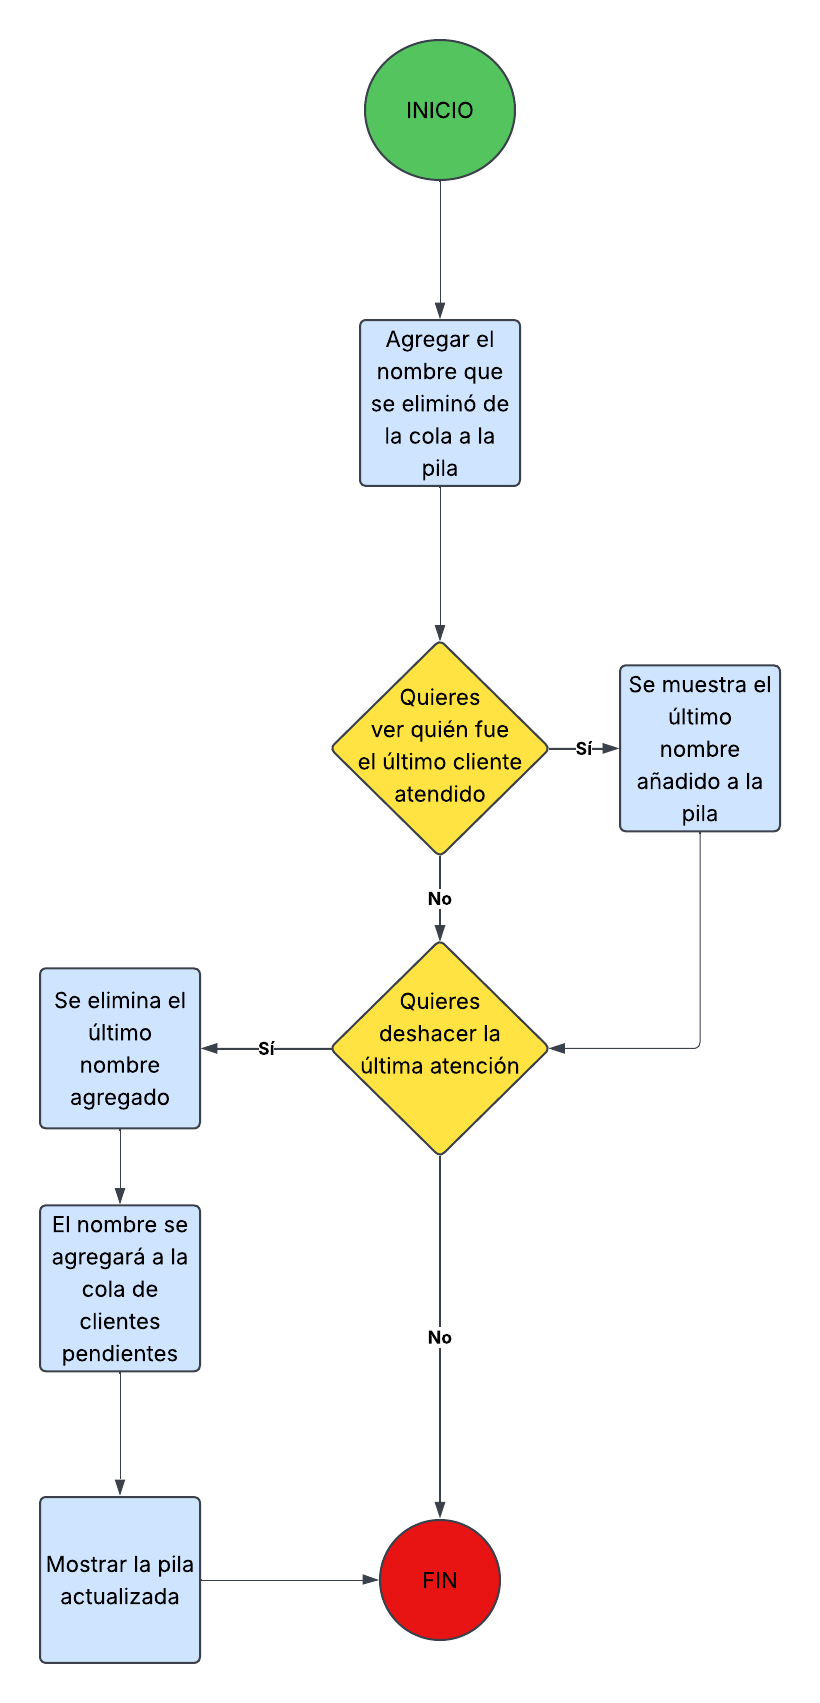


## 5) Diagramas de secuencia **[5 pts]**
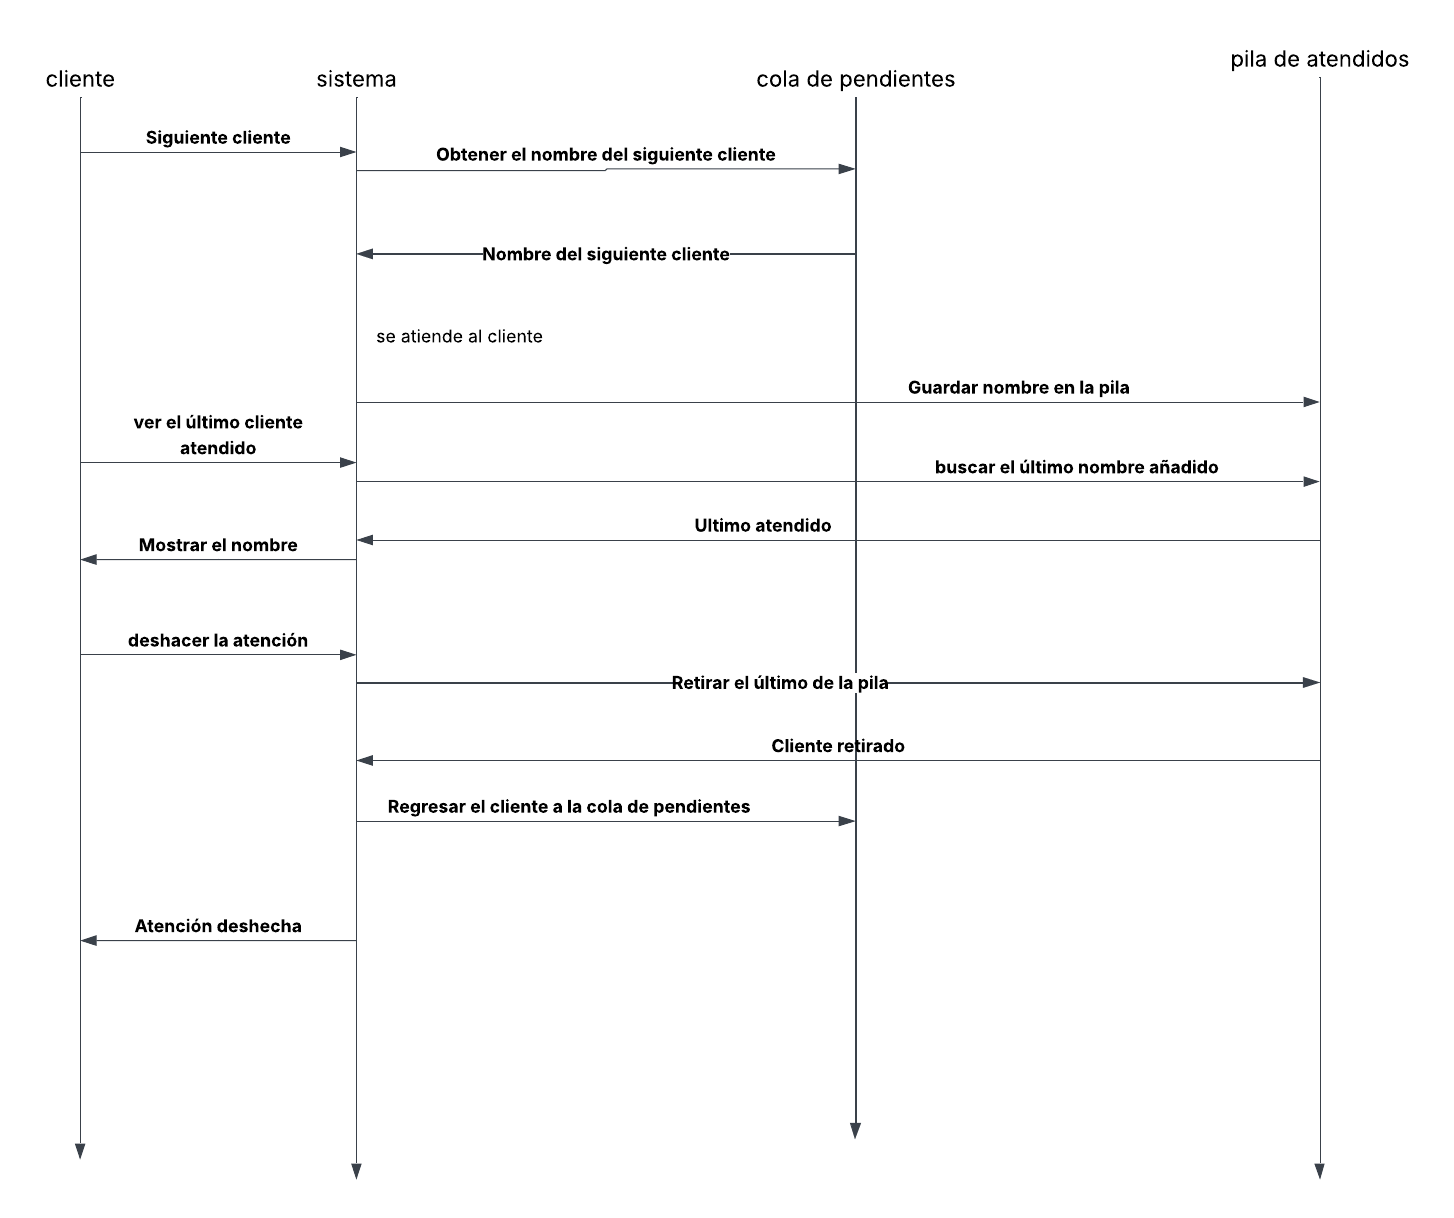

## 6) Diagramas de casos de uso **[5 pts]**
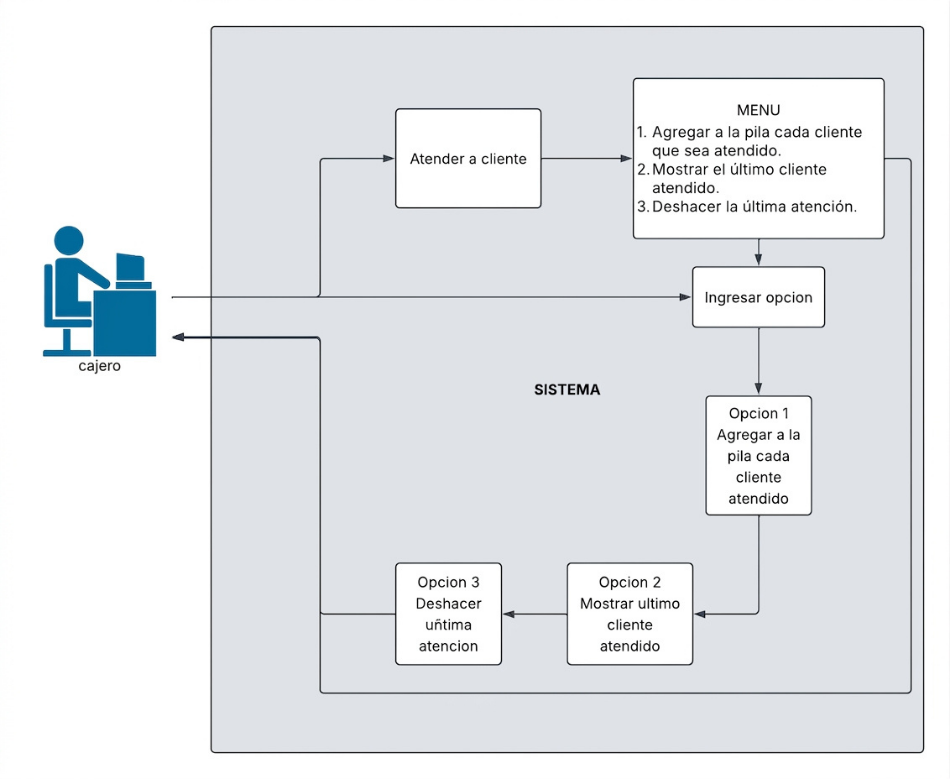

## 7) Análisis de complejidad **[5 pts]**


el mejor caso es T(n) = O(1)
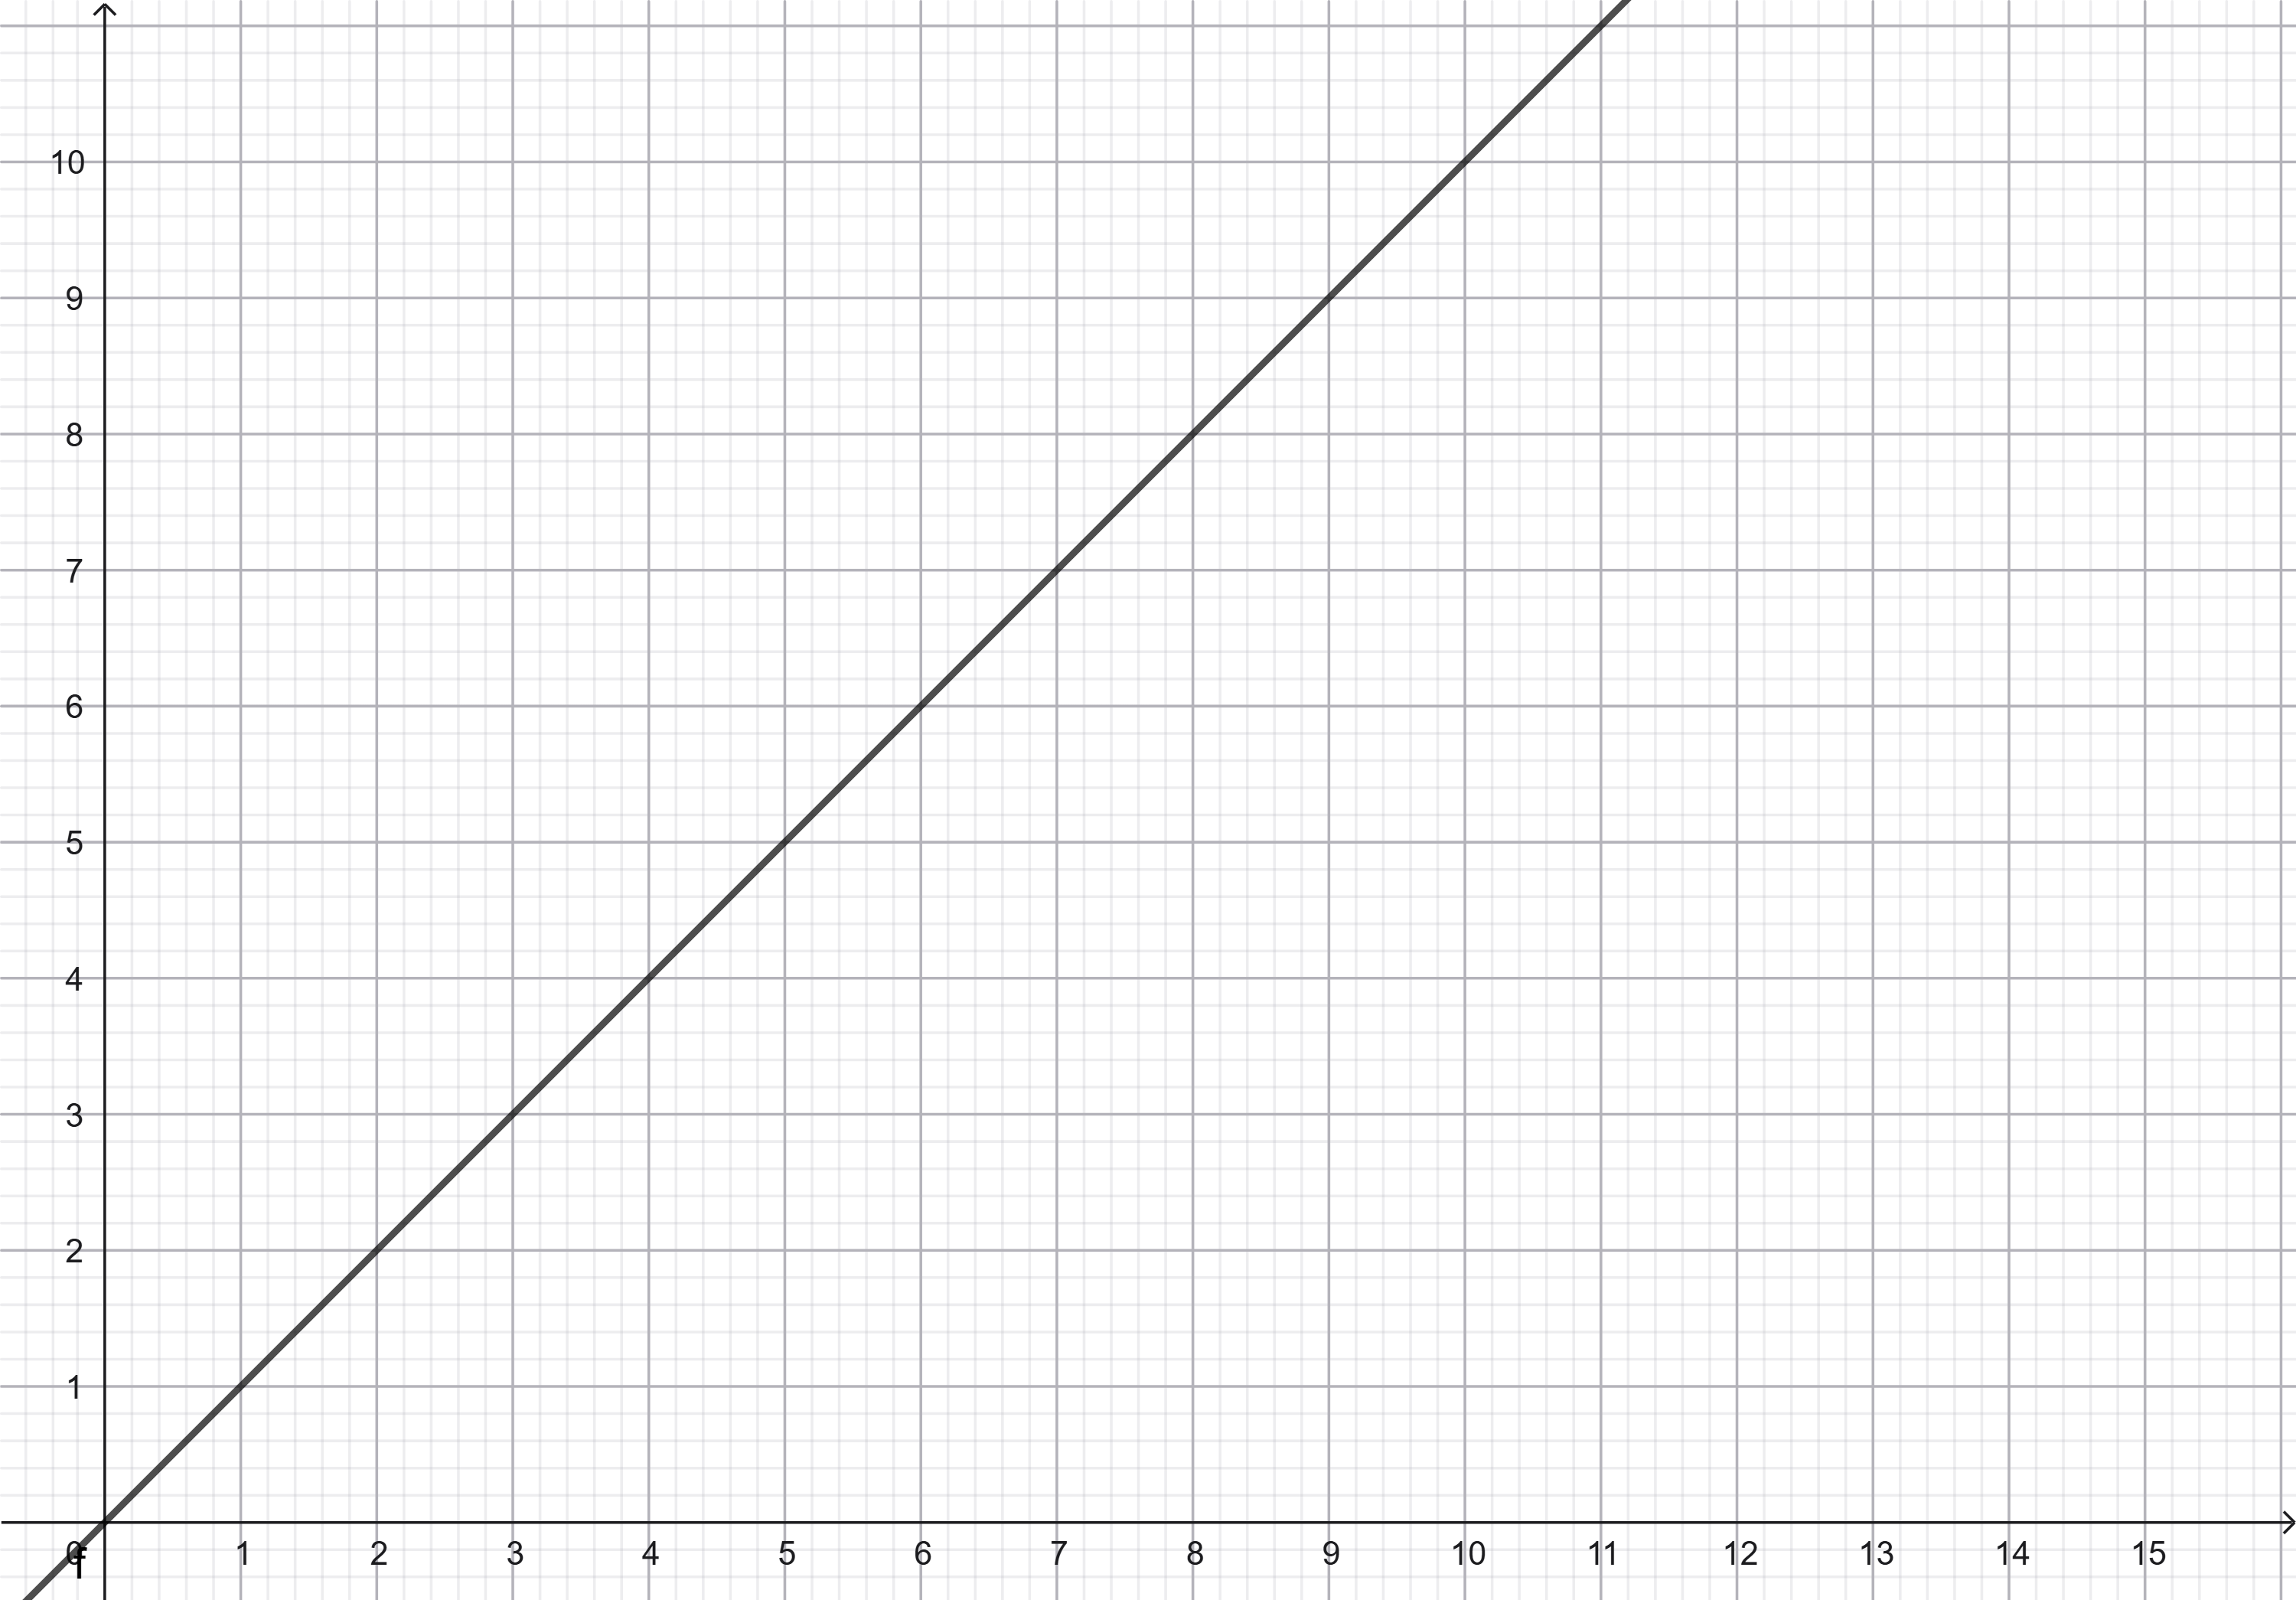

el peor caso es T(n) = O(n)
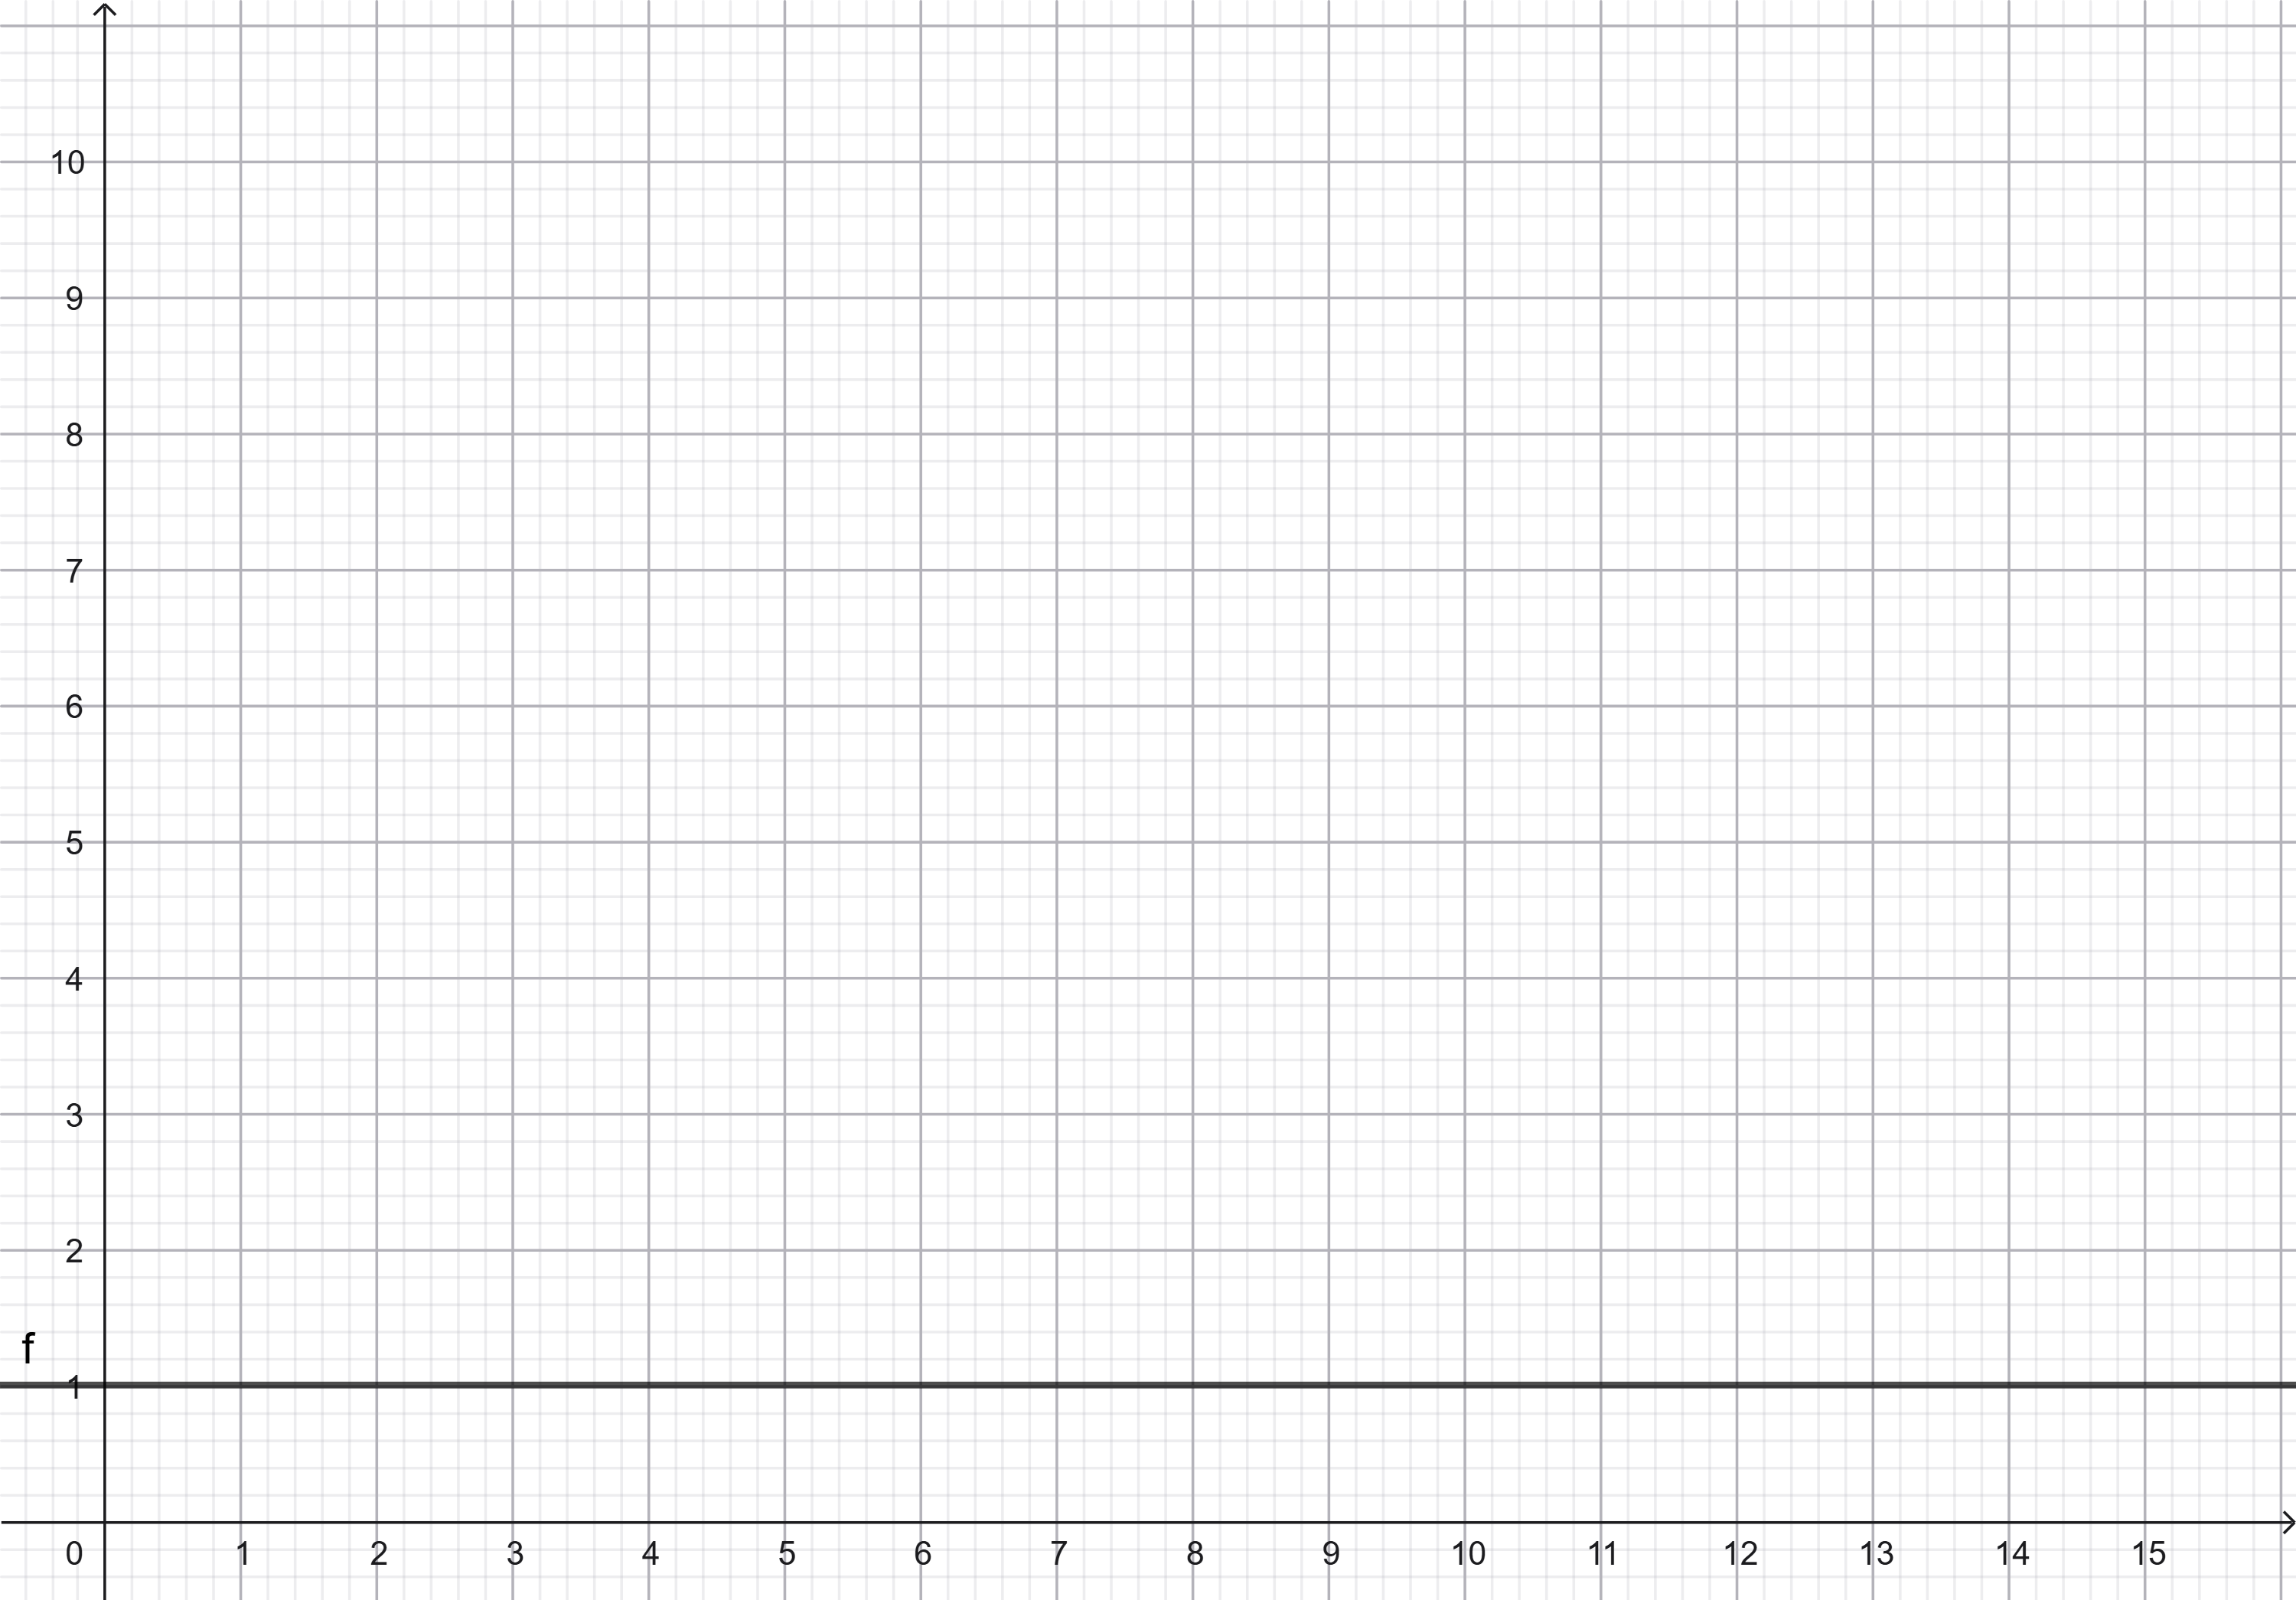

## 8) Código funcional **[10 pts]**


In [ ]:
from collections import deque

def agr_cli(cola, pila):
    nomb = input("Ingrese el nuevo cliente: ")
    cola.append(nomb)
    pila.append("Agrego cliente " + nomb)
    print("Cliente agregado.")

def ate_cli(cola, pila):
    if len(cola) == 0:
        print("No hay clientes esperando.")
    else:
        nomb = cola.popleft()
        pila.append(["atend", nomb])
        print("Atendiendo a:", nomb)

def mos_col(cola):
    if len(cola) == 0:
        print("No hay clientes esperando.")
    else:
        print("Clientes esperando:")
        for i in range(len(cola)):
            if i == len(cola) - 1:
                print(cola[i])
            else:
                print(cola[i], "->", end=" ")

def ult_op(pila):
    if len(pila) == 0:
        print("No hay operaciones.")
    else:
        oper = pila[-1]
        if type(oper) == list:
            print("Ultima operacion: atendio a", oper[1])
        else:
            print("Ultima operacion:", oper)

def mos_pil(pila):
    if len(pila) == 0:
        print("La pila esta vacia.")
    else:
        print("\nHistorial de operaciones:")
        for i in range(len(pila) - 1, -1, -1):
            oper = pila[i]
            if type(oper) == list:
                print("| Atendio a:", oper[1], "|")
            else:
                print("|", oper, "|")
        print("-----------")

def des_ate(cola, pila):
    if len(pila) == 0:
        print("No hay operaciones.")
    else:
        oper = pila[-1]
        if type(oper) == list and oper[0] == "atend":
            oper = pila.pop()
            cola.appendleft(oper[1])
            print("Se deshizo la atencion de:", oper[1])
        else:
            print("La ultima operacion no fue una atencion.")

def agr_pro(prod, pila):
    codi = int(input("Ingrese el codigo: "))
    nomb = input("Ingrese el nombre: ")
    prec = float(input("Ingrese el precio: "))
    nuev = [codi, nomb, prec, None, None]
    if len(prod) == 0:
        prod.append(nuev)
    else:
        ult = prod[-1]
        ult[4] = nuev
        nuev[3] = ult
        prod.append(nuev)
    pila.append("Agrego producto " + nomb)
    print("Producto agregado.")

def mos_ini(prod):
    if len(prod) == 0:
        print("No hay productos.")
    else:
        actu = prod[0]
        print("\nProductos:")
        while actu is not None:
            print(actu[0], "-", actu[1], "- $", actu[2])
            actu = actu[4]

def mos_fin(prod):
    if len(prod) == 0:
        print("No hay productos.")
    else:
        actu = prod[-1]
        print("\nProductos:")
        while actu is not None:
            print(actu[0], "-", actu[1], "- $", actu[2])
            actu = actu[3]

def bus_pro(prod):
    codi = int(input("Ingrese el codigo: "))
    if len(prod) > 0:
        actu = prod[0]
    else:
        actu = None
    while actu is not None:
        if actu[0] == codi:
            print("Producto encontrado")
            print("Codigo:", actu[0])
            print("Nombre:", actu[1])
            print("Precio:", actu[2])
            return
        actu = actu[4]
    print("Producto no encontrado.")

def eli_pro(prod, pila):
    codi = int(input("Ingrese el codigo a eliminar: "))
    if len(prod) > 0:
        actu = prod[0]
    else:
        actu = None
    while actu is not None:
        if actu[0] == codi:
            break
        actu = actu[4]
    if actu is None:
        print("Producto no encontrado.")
        return
    ant = actu[3]
    sig = actu[4]
    if ant is None:
        if sig is not None:
            sig[3] = None
        prod.remove(actu)
    else:
        ant[4] = sig
        if sig is not None:
            sig[3] = ant
        prod.remove(actu)
    pila.append("Elimino producto " + actu[1])
    print("Producto eliminado.")

def men_col(cola, pila):
    opci = 0
    while opci != 4:
        print("\n===== COLA =====\n1. Agregar cliente\n2. Atender cliente\n3. Mostrar clientes\n4. Regresar")
        opci = int(input("Opcion: "))
        if opci == 1:
            agr_cli(cola, pila)
        elif opci == 2:
            ate_cli(cola, pila)
        elif opci == 3:
            mos_col(cola)
        elif opci != 4:
            print("Opcion no valida.")

def men_pil(cola, pila):
    opci = 0
    while opci != 4:
        print("\n===== PILA =====\n1. Mostrar ultima operacion\n2. Mostrar historial\n3. Deshacer ultima atencion\n4. Regresar")
        opci = int(input("Opcion: "))
        if opci == 1:
            ult_op(pila)
        elif opci == 2:
            mos_pil(pila)
        elif opci == 3:
            des_ate(cola, pila)
        elif opci != 4:
            print("Opcion no valida.")

def men_pro(prod, pila):
    opci = 0
    while opci != 6:
        print("\n===== PRODUCTOS =====\n1. Agregar producto\n2. Mostrar de inicio a fin\n3. Mostrar de fin a inicio\n4. Buscar producto\n5. Eliminar producto\n6. Regresar")
        opci = int(input("Opcion: "))
        if opci == 1:
            agr_pro(prod, pila)
        elif opci == 2:
            mos_ini(prod)
        elif opci == 3:
            mos_fin(prod)
        elif opci == 4:
            bus_pro(prod)
        elif opci == 5:
            eli_pro(prod, pila)
        elif opci != 6:
            print("Opcion no valida.")

def main():
    cola = deque()
    pila = []
    prod = []
    print("===== SISTEMA DE TIENDA =====")
    n = int(input("Cuantos clientes desea registrar?: "))
    for i in range(n):
        nomb = input("Ingrese cliente " + str(i + 1) + ": ")
        cola.append(nomb)
    opci = 0
    while opci != 4:
        print("\n===== MENU PRINCIPAL =====\n1. Cola de clientes\n2. Pila de operaciones\n3. Catalogo de productos\n4. Salir")
        opci = int(input("Opcion: "))
        if opci == 1:
            men_col(cola, pila)
        elif opci == 2:
            men_pil(cola, pila)
        elif opci == 3:
            men_pro(prod, pila)
        elif opci != 4:
            print("Opcion no valida.")
    print("Programa finalizado.")

main()


===== SISTEMA DE TIENDA =====


KeyboardInterrupt: Interrupted by user

## 9) pruebas **[15 pts]**

In [ ]:
from collections import deque

def agr_cli(cola, pila, nomb):
    cola.append(nomb)
    pila.append("Agrego cliente " + nomb)
    print("Cliente agregado:", nomb)

def ate_cli(cola, pila):
    if len(cola) == 0:
        print("No hay clientes esperando.")
    else:
        nomb = cola.popleft()
        pila.append(["atend", nomb])
        print("Atendiendo a:", nomb)

def des_ate(cola, pila):
    if len(pila) == 0:
        print("No hay operaciones.")
    else:
        oper = pila[-1]

        if type(oper) == list and oper[0] == "atend":
            oper = pila.pop()
            cola.appendleft(oper[1])
            print("Se deshizo la atencion de:", oper[1])
        else:
            print("La ultima operacion no fue una atencion.")

def agr_pro(prod, pila, codi, nomb, prec):
    nuev = [codi, nomb, prec, None, None]

    if len(prod) == 0:
        prod.append(nuev)
    else:
        ult = prod[-1]
        ult[4] = nuev
        nuev[3] = ult
        prod.append(nuev)
    pila.append("Agrego producto " + nomb)
    print("Producto agregado:", nomb)

def eli_pro(prod, pila, codi):
    if len(prod) > 0:
        actu = prod[0]
    else:
        actu = None
    while actu is not None:
        if actu[0] == codi:
            break
        actu = actu[4]
    if actu is None:
        print("Producto no encontrado.")
        return
    ant = actu[3]
    sig = actu[4]
    if ant is None:
        if sig is not None:
            sig[3] = None

        prod.remove(actu)
    else:
        ant[4] = sig

        if sig is not None:
            sig[3] = ant
        prod.remove(actu)
    pila.append("Elimino producto " + actu[1])
    print("Producto eliminado:", actu[1])

def mos_col(cola):
    if len(cola) == 0:
        print("No hay clientes esperando.")
    else:
        print("Clientes esperando: ", end="")
        cola_list = list(cola)
        for i in range(len(cola_list)):
            if i == len(cola_list) - 1:
                print(cola_list[i])
            else:
                print(cola_list[i], "->", end=" ")

def mos_ini(prod):
    if len(prod) == 0:
        print("No hay productos.")
    else:
        actu = prod[0]
        print("Productos:")
        while actu is not None:
            if actu[4] is None:
                print(actu[0], "-", actu[1], "- $", actu[2])
            else:
                print(actu[0], "-", actu[1], "- $", actu[2], "<->", end=" ")
            actu = actu[4]

In [ ]:
def test(clientes_iniciales, nuevo_cliente, producto_eliminar, productos_iniciales):
    cola = deque(clientes_iniciales)
    pila = []
    prod = []
    print("\nPUNTO 1. COLA DE CLIENTES")
    print("Estado inicial de la cola:")
    mos_col(cola)
    cliente_atendido_1 = cola[0]
    ate_cli(cola, pila)
    mos_col(cola)
    print(f"\nLlega nuevo cliente: {nuevo_cliente}")
    agr_cli(cola, pila, nuevo_cliente)
    mos_col(cola)
    estado_esperado_cola = clientes_iniciales[1:] + [nuevo_cliente]
    assert list(cola) == estado_esperado_cola, f"Fallo: Esperado {estado_esperado_cola}, pero se obtuvo {list(cola)}"
    print("\nPUNTO 2. PILA DE OPERACIONES")
    cliente_atendido_2 = cola[0]
    tope_pila_antes_de_atender = pila[-1] if pila else None
    ate_cli(cola, pila)
    print("\nDeshaciendo última atención...")
    des_ate(cola, pila)
    print("\nEstado de la cola tras deshacer:")
    mos_col(cola)
    assert cola[0] == cliente_atendido_2, f"Fallo: El cliente {cliente_atendido_2} no regresó al inicio de la cola."
    assert pila[-1] == tope_pila_antes_de_atender, "Fallo: El tope de la pila no se restauró correctamente."
    print("\nPUNTO 3. LISTA DOBLEMENTE ENLAZADA ")
    for p in productos_iniciales:
        agr_pro(prod, pila, p["cod"], p["nom"], p["prec"])
    print("\nCatálogo inicial:")
    mos_ini(prod)
    print(f"\nEliminando producto código: {producto_eliminar}")
    eli_pro(prod, pila, producto_eliminar)
    print("\nCatálogo tras eliminación:")
    mos_ini(prod)
    assert len(prod) == len(productos_iniciales) - 1, "Fallo: La cantidad de productos no disminuyó en 1."
    for p in prod:
        assert p[0] != producto_eliminar, f"Fallo: El producto con código {producto_eliminar} no fue eliminado."
    for i in range(len(prod)):
        if i > 0:
            assert prod[i][3] == prod[i-1], f"Fallo: El enlace 'anterior' de {prod[i][1]} está roto."
        if i < len(prod) - 1: #
            assert prod[i][4] == prod[i+1], f"Fallo: El enlace 'siguiente' de {prod[i][1]} está roto."

_IncompleteInputError: incomplete input (1466653852.py, line 2)

## Pruebas de enunciado


In [ ]:
datos_clientes_iniciales = ["Ana", "Carlos", "Laura", "Mateo"]
dato_nuevo_cliente = "Sofía"
datos_productos = [
    {"cod": 101, "nom": "Arroz", "prec": 4500},
    {"cod": 102, "nom": "Leche", "prec": 3800},
    {"cod": 103, "nom": "Pan",   "prec": 2500},
    {"cod": 104, "nom": "Café",  "prec": 12000},
]
dato_producto_eliminar = 103
test(
    clientes_iniciales=datos_clientes_iniciales,
    nuevo_cliente=dato_nuevo_cliente,
    producto_eliminar=dato_producto_eliminar,
    productos_iniciales=datos_productos
))

Paso caso de prueba 123 -> 123


## Pruebas propias


In [ ]:
datos_clientes_iniciales = ["A", "B"]
dato_nuevo_cliente = "C"
datos_productos = [
    {"cod": 1, "nom": "Chocolate", "prec": 2300},
    {"cod": 2, "nom": "Papas", "prec": 1500},
    {"cod": 3, "nom": "Gaseosa",   "prec": 4700},
    {"cod": 4, "nom": "Dulces",  "prec": 2000},
]
dato_producto_eliminar = 3
test(
    clientes_iniciales=datos_clientes_iniciales,
    nuevo_cliente=dato_nuevo_cliente,
    producto_eliminar=dato_producto_eliminar,
    productos_iniciales=datos_productos
)

Paso caso de prueba 123 -> 123


## Pruebas de Desempeño


Generando datos ............

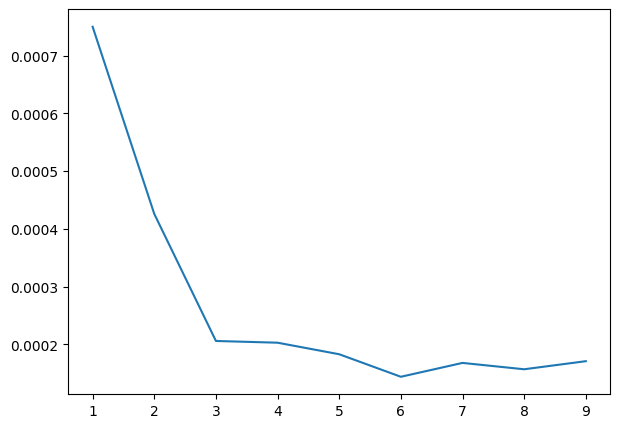

In [ ]:
# Calcula el tiempo de ejecucion con base a diferentes tamaños de la entrada

# y nos da una lista de resultados, cada resultado contiene el tamaño de la entrada

# y el tiempo de ejecucion

# TENER EN CUENTA ESTAS ENTRADAS PUEDEN VARIAR SEGÚN EL PROBLEMA





def bench(n: int, step: int = 1) -> list[tuple[int, float]]:
    print("Generando datos ...", end='')
    from random import randint
    import time
    results: list[tuple[int, float]] = []


    # AJUSTAR LAS ENTRADAS SEGÚN EL PROBLEMA
    for size in range(1, n, step):
        input = size

        ti = time.perf_counter()
        output = input # Ajustar a su función
        tf = time.perf_counter()


        delta = (tf - ti) * 1000
        print(".", end="")
        results.append((size, delta))
    return results


# === CODIGO PARA DIBUJAR ===


def dibujar(x, y, dimensiones=(7, 5)):
    assert len(x) == len(y)
    import matplotlib.pyplot as plt
    plt.figure(figsize=dimensiones)
    plt.plot(x, y)
    plt.show()


# === LLAMADO ===
tiempos = bench(10, step=1)


x = [size for size, timing in tiempos]
y = [timing for size, timing in tiempos]


dibujar(x, y)

